# **Before analysis**

## Unzip

In [1]:
!unzip -q "/content/drive/MyDrive/Leimen /Results - 2026 07 15/mouse_movement_data.zip" -d "./"

unzip:  cannot find either /content/drive/MyDrive/Leimen /Results - 2026 07 15/mouse_movement_data.zip or /content/drive/MyDrive/Leimen /Results - 2026 07 15/mouse_movement_data.zip.zip.


In [ ]:
!pip install scikit-posthocs

## Data overview

In [ ]:
import os
import json
import msgpack

folder_path = "./mouse_movement_data"

# 1. read the first file
bin_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.bin')])
first_file = bin_files[0]
file_path = os.path.join(folder_path, first_file)
print(f"Reading: {first_file}\n")

events = []

# 2. use messagepack to transform bin back to json
with open(file_path, "rb") as f:
    # raw=False, binary to UTF-8
    # msgpack.Unpacker, package dealing with continuous write in
    unpacker = msgpack.Unpacker(f, raw=False)
    for item in unpacker:
        # List [{}, {}, {}]
        if isinstance(item, list):
            events.extend(item)


# 3. print total event numbers & first 10 events
print(f"total events num: {len(events)}\n")

if len(events) > 0:
    print("first 10 events:")
    print(json.dumps(events[:10], ensure_ascii=False, indent=2))
else:
    print("No events。")

Reading: 002267ef-1893-4bb5-8b7b-cc0e6512c0d0_1783930782.bin

total events num: 3658

first 10 events:
[
  {
    "type": "viewport",
    "innerWidth": 1920,
    "innerHeight": 945,
    "devicePixelRatio": 1,
    "scrollWidth": 1920,
    "scrollHeight": 945,
    "screenWidth": 1920,
    "screenHeight": 1080,
    "userAgent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/150.0.0.0 Safari/537.36",
    "ts": 1783930570098
  },
  {
    "type": "pointer-over",
    "element": "page-background",
    "x": 1254,
    "y": 806,
    "ts": 1783930570099,
    "pointerType": "mouse"
  },
  {
    "type": "scroll",
    "x": 0,
    "y": 0,
    "ts": 1783930570099,
    "scrollX": 0,
    "scrollY": 0,
    "direction": "up"
  },
  {
    "type": "pointer-over",
    "element": "susceptibility-weo-scenario",
    "x": 1254,
    "y": 806,
    "ts": 1783930570260,
    "pointerType": "mouse"
  },
  {
    "type": "pointer-move",
    "x": 1254,
    "y": 805,
    "ts": 17839

## Print all types & elements

In [ ]:
import os
import msgpack

folder_path = "./mouse_movement_data"
bin_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.bin')])
file_path = os.path.join(folder_path, bin_files[0])

unique_elements = set()
unique_types = set()

with open(file_path, "rb") as f:
    unpacker = msgpack.Unpacker(f, raw=False)
    for item in unpacker:
        events = item if isinstance(item, list) else [item] if isinstance(item, dict) else []
        for event in events:
            # get element & type
            elem = event.get('element')
            if elem:
                unique_elements.add(elem)

            evt_type = event.get('type')
            if evt_type:
                unique_types.add(evt_type)

print("-- All Event Types --")
print(" ")
for t in sorted(list(unique_types)):
    print(f"- {t}")

print(" ")
print("All Elements")
print(" ")
for e in sorted(list(unique_elements)):
    print(f"- {e}")



-- All Event Types --
 
- element-rect
- pointer-down
- pointer-move
- pointer-out
- pointer-over
- pointer-up
- scroll
- slider-change
- viewport
 
All Elements
 
- docpref-q1
- docpref-q2
- docpref-q3
- docrec-image
- docrec-note
- docrec-reminders
- efficacy-response
- efficacy-self
- page-background
- page-intro
- page-next
- postsurvey-intro
- postsurvey-submit
- pq1-confirm
- pq1-element
- pq1-label
- pq1-slider
- pq2-confirm
- pq2-element
- pq2-slider
- pq3-confirm
- pq3-element
- pq3-label
- pq3-slider
- q1-confirm
- q1-element
- q1-slider
- q10-confirm
- q10-element
- q10-slider
- q11-confirm
- q11-element
- q11-slider
- q12-confirm
- q12-element
- q12-slider
- q2-confirm
- q2-element
- q2-slider
- q3-confirm
- q3-element
- q3-slider
- q4-confirm
- q4-element
- q4-label
- q4-slider
- q5-confirm
- q5-element
- q5-label
- q5-slider
- q6-confirm
- q6-element
- q6-slider
- q7-confirm
- q7-element
- q7-slider
- q8-confirm
- q8-element
- q8-slider
- q9-confirm
- q9-element
- q9-slid

# **Hypothesis: Diet Score**

H1. Participants who receive the hope appeal report lower diet scores than those who do not.

H2. Participants who use the RAM slider report lower diet scores than those who use the control slider.

H3. The most significant difference in self-reported health scores is observed between the Control group and the RAM + Hope Appeal group.

In [ ]:
import os
import msgpack
import pandas as pd

folder_path = "./mouse_movement_data"
bin_files = sorted([f for f in os.listdir(folder_path) if f.endswith(".bin")])

# True  = a question counts only if the participant actually clicked its confirm button
# False = take the last slider value regardless of confirm
# Run both and compare (diagnostic at the bottom) before committing to one.
REQUIRE_CONFIRM = True

results = []

for file_name in bin_files:

    file_path = os.path.join(folder_path, file_name)

    events = []

    with open(file_path, "rb") as f:
        unpacker = msgpack.Unpacker(f, raw=False)

        for item in unpacker:
            if isinstance(item, list):
                events.extend(item)
            elif isinstance(item, dict):
                events.append(item)

    # latest value seen on each slider
    current_slider_value = {}

    # phase that produced the latest value (for provenance)
    current_slider_phase = {}

    # value at the moment confirm was clicked
    confirmed_scores = {}

    # last value seen, ignoring confirm entirely
    last_value_scores = {}

    n_confirm_clicks = 0

    for event in events:

        element = event.get("element")
        evt_type = event.get("type")

        if element is None:
            continue

        # -----------------------
        # slider event
        # -----------------------
        if element.endswith("-slider"):

            # Only slider-change carries `value`. Do not rely on other event
            # types happening to lack the key.
            if evt_type != "slider-change":
                continue

            value = event.get("value")

            if value is not None:
                current_slider_value[element] = float(value)
                current_slider_phase[element] = event.get("phase")
                last_value_scores[element] = float(value)

        # -----------------------
        # confirm event
        # -----------------------
        elif element.endswith("-confirm"):

            # BUG FIX: this used to fire on any event, including pointer-move
            # and pointer-over. Merely hovering the confirm button snapshotted
            # the value. Only an actual click counts.
            if evt_type not in ("pointer-down", "pointer-up"):
                continue

            n_confirm_clicks += 1

            slider_name = element.replace("-confirm", "-slider")

            if slider_name in current_slider_value:
                confirmed_scores[slider_name] = current_slider_value[slider_name]

    # -----------------------
    # subject average
    # -----------------------
    final_scores = confirmed_scores if REQUIRE_CONFIRM else last_value_scores

    scores = []
    n_from_press = 0

    for i in range(1, 13):

        key = f"q{i}-slider"

        if key in final_scores:
            scores.append(final_scores[key])

            # press-only questions: participant accepted the slider's starting
            # value (0 for RAM, 9 for control). This is a real answer, kept.
            if current_slider_phase.get(key) == "press":
                n_from_press += 1

    avg_score = sum(scores) / len(scores) if scores else None

    # same subject scored under the other rule, for the diagnostic below
    alt = last_value_scores if REQUIRE_CONFIRM else confirmed_scores
    alt_scores = [alt[f"q{i}-slider"] for i in range(1, 13) if f"q{i}-slider" in alt]
    alt_avg = sum(alt_scores) / len(alt_scores) if alt_scores else None

    results.append({
        "subject_id": file_name.replace(".bin", ""),
        "diet_score": avg_score,
        "valid_q_count": len(scores),
        "n_from_press": n_from_press,
        "n_confirm_clicks": n_confirm_clicks,
        "alt_diet_score": alt_avg,
        "alt_valid_q_count": len(alt_scores),
    })

df_results = pd.DataFrame(results)

print(df_results.head(10))

df_results.to_csv("subject_diet_score.csv", index=False)

print("Saved as subject_diet_score.csv")

                                        subject_id  diet_score  valid_q_count  \
0  002267ef-1893-4bb5-8b7b-cc0e6512c0d0_1783930782    5.333333             12   
1  014d483f-deb7-463a-8600-c4e7e3f291b2_1784027952    4.583333             12   
2  01dff38e-a919-483b-b6d7-cf30df8f6a2c_1783930816    6.333333             12   
3  037b5b1a-6596-415d-9860-cfe1ce971b96_1783932088    6.833333             12   
4  041f4926-3329-47ed-a32b-89075db59841_1784016685    2.083333             12   
5  070dfe9d-695e-4966-aea5-c07c2b671b49_1783935395    6.333333             12   
6  07d7b054-5f23-4184-ba7a-3cff3af1ec8d_1783930223    6.333333             12   
7  0826e08e-f4c0-4b86-818d-8b11788e625b_1783933257    3.250000             12   
8  08471ad8-cf33-4d58-a9cf-b1625e1d30e7_1783935959    9.000000             12   
9  091f35d9-e7fa-4ee2-8fb5-5a3ff9f788f5_1783939534    2.666667             12   

   n_from_press  n_confirm_clicks  alt_diet_score  alt_valid_q_count  
0             0                30    

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scikit_posthocs as sp


df_dietscore = pd.read_csv('subject_diet_score.csv')
df_cond = pd.read_csv('/content/drive/MyDrive/Leimen /Results - 2026 07 15/userid_condition.csv')

# left join to match subject speed dataset
df_dietscore['clean_id'] = df_dietscore['subject_id'].apply(lambda x: str(x).split('_')[0])
df = pd.merge(df_dietscore, df_cond, left_on='clean_id', right_on='respondent_id', how='left')

# drop average speed = 0
df = df.dropna(subset=['diet_score', 'condition'])

# Group HopeApeal and RAM
df['Factor_HopeAppeal'] = df['condition'].apply(lambda x: 'HopeAppeal' if str(x).startswith('wEO') else 'non-HopeAppeal')
df['Factor_RAM'] = df['condition'].apply(lambda x: 'RAM (wRAM)' if str(x).endswith('-wRAM') else 'non-RAM (woRAM)')


print(f"Sample size：{len(df)}")
print("\n")




Sample size：291




In [ ]:
# general statistics
desc_stats = df.groupby('condition')['diet_score'].agg(N='count', Mean='mean', Median='median', Std='std').round(2)
print(desc_stats)
print("\n")

             N  Mean  Median   Std
condition                         
wEO-wRAM    73  5.22    5.17  1.44
wEO-woRAM   67  5.57    5.67  1.42
woEO-wRAM   75  4.79    4.75  1.39
woEO-woRAM  76  5.63    5.42  1.80




In [ ]:
print("-- Main Effect - Mann Whitney Test --")

# Test 1: HopeAppeal (wEO) vs non-HopeAppeal (woEO)
group_HopeAppeal = df[df['Factor_HopeAppeal'] == 'HopeAppeal']['diet_score']
group_nonHopeAppeal = df[df['Factor_HopeAppeal'] == 'non-HopeAppeal']['diet_score']
stat_ha, p_ha = stats.mannwhitneyu(group_HopeAppeal, group_nonHopeAppeal, alternative='two-sided')
print(f"▶ HopeAppeal vs non-HopeAppeal:")
print(f"  median = {group_HopeAppeal.median():.3f} vs {group_nonHopeAppeal.median():.3f}")
print(f"  mean = {group_HopeAppeal.mean():.3f} vs {group_nonHopeAppeal.mean():.3f}")
print(f"  U-statistic = {stat_ha:.2f}, p-value = {p_ha:.4f}")

# Test 2: RAM vs non-RAM
group_RAM = df[df['Factor_RAM'] == 'RAM (wRAM)']['diet_score']
group_nonRAM = df[df['Factor_RAM'] == 'non-RAM (woRAM)']['diet_score']
stat_ram, p_ram = stats.mannwhitneyu(group_RAM, group_nonRAM, alternative='two-sided')
print(f"▶ RAM vs non-RAM:")
print(f"  median = {group_RAM.median():.3f} vs {group_nonRAM.median():.3f}")
print(f"  mean = {group_RAM.mean():.3f} vs {group_nonRAM.mean():.3f}")
print(f"  U-statistic = {stat_ram:.2f}, p-value = {p_ram:.4f}")
print("\n")

-- Main Effect - Mann Whitney Test --
▶ HopeAppeal vs non-HopeAppeal:
  median = 5.417 vs 5.000
  mean = 5.388 vs 5.210
  U-statistic = 11582.00, p-value = 0.1584
▶ RAM vs non-RAM:
  median = 5.000 vs 5.583
  mean = 5.002 vs 5.598
  U-statistic = 8239.00, p-value = 0.0011




In [ ]:
print("-- H1: Hope Appeal effect, stratified by slider --")

for slider in ['RAM (wRAM)', 'non-RAM (woRAM)']:
    sub = df[df['Factor_RAM'] == slider]
    a = sub[sub['Factor_HopeAppeal'] == 'HopeAppeal']['diet_score']
    b = sub[sub['Factor_HopeAppeal'] == 'non-HopeAppeal']['diet_score']

    stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    r = 2 * stat / (len(a) * len(b)) - 1          # rank-biserial effect size

    print(f"\n▶ [{slider}] wEO vs woEO:")
    print(f"  n = {len(a)} vs {len(b)}")
    print(f"  median = {a.median():.3f} vs {b.median():.3f}")
    print(f"  U-statistic = {stat:.2f}, p-value = {p:.4f}, r = {r:+.3f}")

    # H1 predicts wEO < woEO; two-sided p carries no direction, so check medians
    hit = (p < .05) and (a.median() < b.median())
    warn = "  ⚠️ significant but direction is opposite" if (p < .05 and a.median() >= b.median()) else ""
    print(f"  -> {'✅ supports H1' if hit else '❌ not supported'}{warn}")

-- H1: Hope Appeal effect, stratified by slider --

▶ [RAM (wRAM)] wEO vs woEO:
  n = 73 vs 75
  median = 5.167 vs 4.750
  U-statistic = 3216.00, p-value = 0.0667, r = +0.175
  -> ❌ not supported

▶ [non-RAM (woRAM)] wEO vs woEO:
  n = 67 vs 76
  median = 5.667 vs 5.417
  U-statistic = 2545.50, p-value = 1.0000, r = -0.000
  -> ❌ not supported


In [ ]:
print("-- Four Groups：Kruskal-Wallis & Dunn's Posthoc --")
conds = df['condition'].unique()
kw_data = [df[df['condition'] == c]['diet_score'] for c in conds]

stat_kw, p_kw = stats.kruskal(*kw_data)
print(f"Kruskal-Wallis H-statistic = {stat_kw:.2f}, p-value = {p_kw:.4f}")

dunn_matrix = sp.posthoc_dunn(df, val_col='diet_score', group_col='condition', p_adjust='holm')
print("\n▶ Dunn's post-hoc (p-value matrix, Holm correction):")
print(dunn_matrix.round(4))
print("\n")
from itertools import combinations

# 統一順序，跟 Table 8.1 對齊
order = ["wEO-wRAM", "wEO-woRAM", "woEO-wRAM", "woEO-woRAM"]

med = df.groupby('condition')['diet_score'].median()
df['_rank'] = df['diet_score'].rank()          # 全體排秩，Dunn's 的基礎
mr = df.groupby('condition')['_rank'].mean()

print("\n▶ Pairwise differences (median / mean rank):")
rows = []
for a, b in combinations(order, 2):
    rows.append({
        "comparison":  f"{a} − {b}",
        "median_diff": med[a] - med[b],
        "rank_diff":   mr[a] - mr[b],
        "p_holm":      dunn_matrix.loc[a, b],
    })

diff_table = pd.DataFrame(rows)
diff_table["sig"] = np.where(diff_table["p_holm"] < .05, "*", "")
print(diff_table.round(4).to_string(index=False))

df.drop(columns='_rank', inplace=True)

-- Four Groups：Kruskal-Wallis & Dunn's Posthoc --
Kruskal-Wallis H-statistic = 13.93, p-value = 0.0030

▶ Dunn's post-hoc (p-value matrix, Holm correction):
            wEO-wRAM  wEO-woRAM  woEO-wRAM  woEO-woRAM
wEO-wRAM      1.0000     0.3614     0.2999      0.4012
wEO-woRAM     0.3614     1.0000     0.0057      0.7519
woEO-wRAM     0.2999     0.0057     1.0000      0.0101
woEO-woRAM    0.4012     0.7519     0.0101      1.0000



▶ Pairwise differences (median / mean rank):
            comparison  median_diff  rank_diff  p_holm sig
  wEO-wRAM − wEO-woRAM      -0.5000   -22.1030  0.3614    
  wEO-wRAM − woEO-wRAM       0.4167    24.6307  0.2999    
 wEO-wRAM − woEO-woRAM      -0.2500   -17.6454  0.4012    
 wEO-woRAM − woEO-wRAM       0.9167    46.7337  0.0057   *
wEO-woRAM − woEO-woRAM       0.2500     4.4577  0.7519    
woEO-wRAM − woEO-woRAM      -0.6667   -42.2761  0.0101   *


In [ ]:
print("-- Pairwise Mann-Whitney U --")
mw_matrix = sp.posthoc_mannwhitney(df, val_col='diet_score', group_col='condition', p_adjust='holm')
print("\n▶ Pairwise Mann-Whitney U (p-value matrix, Holm correction):")
print(mw_matrix.round(4))
print("\n")

from itertools import combinations
from scipy import stats

order = ["wEO-wRAM", "wEO-woRAM", "woEO-wRAM", "woEO-woRAM"]
mw_matrix = mw_matrix.loc[order, order]

med = df.groupby('condition')['diet_score'].median()

print("\n▶ Pairwise differences (median diff / rank-biserial r):")
rows = []
for a, b in combinations(order, 2):
    xa = df.loc[df['condition'] == a, 'diet_score']
    xb = df.loc[df['condition'] == b, 'diet_score']
    u, _ = stats.mannwhitneyu(xa, xb, alternative='two-sided')
    r_rb = 2 * u / (len(xa) * len(xb)) - 1        # −1 ~ +1, 正值代表 a > b
    rows.append({
        "comparison":  f"{a} − {b}",
        "median_diff": med[a] - med[b],
        "U":           u,
        "r_rb":        r_rb,
        "p_holm":      mw_matrix.loc[a, b],
    })

mw_table = pd.DataFrame(rows)
mw_table["sig"] = np.where(mw_table["p_holm"] < .05, "*", "")
print(mw_table.round(4).to_string(index=False))

-- Pairwise Mann-Whitney U --

▶ Pairwise Mann-Whitney U (p-value matrix, Holm correction):
            wEO-wRAM  wEO-woRAM  woEO-wRAM  woEO-woRAM
wEO-wRAM      1.0000     0.2667     0.2667      0.4750
wEO-woRAM     0.2667     1.0000     0.0033      1.0000
woEO-wRAM     0.2667     0.0033     1.0000      0.0198
woEO-woRAM    0.4750     1.0000     0.0198      1.0000



▶ Pairwise differences (median diff / rank-biserial r):
            comparison  median_diff      U    r_rb  p_holm sig
  wEO-wRAM − wEO-woRAM      -0.5000 2034.0 -0.1683  0.2667    
  wEO-wRAM − woEO-wRAM       0.4167 3216.0  0.1748  0.2667    
 wEO-wRAM − woEO-woRAM      -0.2500 2462.5 -0.1123  0.4750    
 wEO-woRAM − woEO-wRAM       0.9167 3358.0  0.3365  0.0033   *
wEO-woRAM − woEO-woRAM       0.2500 2545.5 -0.0002  1.0000    
woEO-wRAM − woEO-woRAM      -0.6667 2075.5 -0.2718  0.0198   *


## Plots

/tmp/ipykernel_881/1154773170.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Factor_HopeAppeal', y='diet_score', palette=["#72B6A1", "#E9967A"])


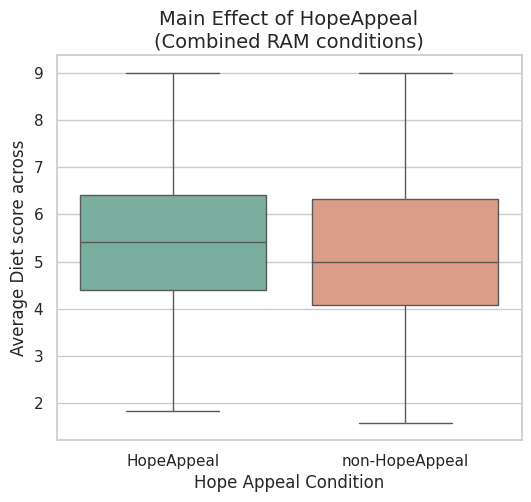

In [ ]:
sns.set_theme(style="whitegrid")

# HopeAppeal Main effect Boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='Factor_HopeAppeal', y='diet_score', palette=["#72B6A1", "#E9967A"])
plt.title('Main Effect of HopeAppeal\n(Combined RAM conditions)', fontsize=14)
plt.ylabel('Average Diet score across')
plt.xlabel('Hope Appeal Condition')
plt.show()

print("\n")

/tmp/ipykernel_881/986594790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Factor_RAM', y='diet_score', palette=["#72B6A1", "#E9967A"])


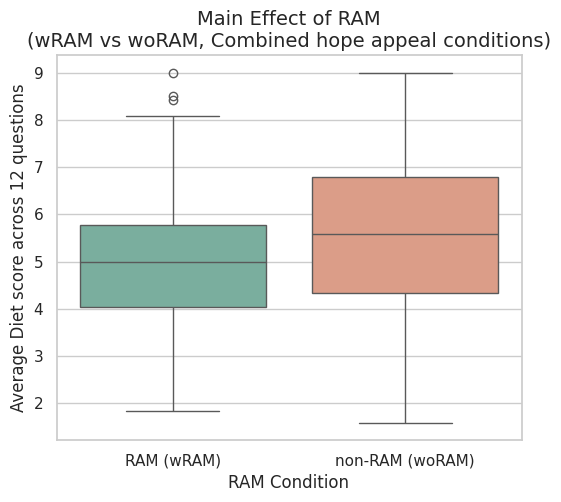

In [ ]:
sns.set_theme(style="whitegrid")

# RAM Main effect Boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='Factor_RAM', y='diet_score', palette=["#72B6A1", "#E9967A"])
plt.title('Main Effect of RAM\n(wRAM vs woRAM, Combined hope appeal conditions)', fontsize=14)
plt.ylabel('Average Diet score across 12 questions')
plt.xlabel('RAM Condition')
plt.show()

print("\n")

/tmp/ipykernel_881/24192502.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.assign(condition=df["condition"].map(label_map)),


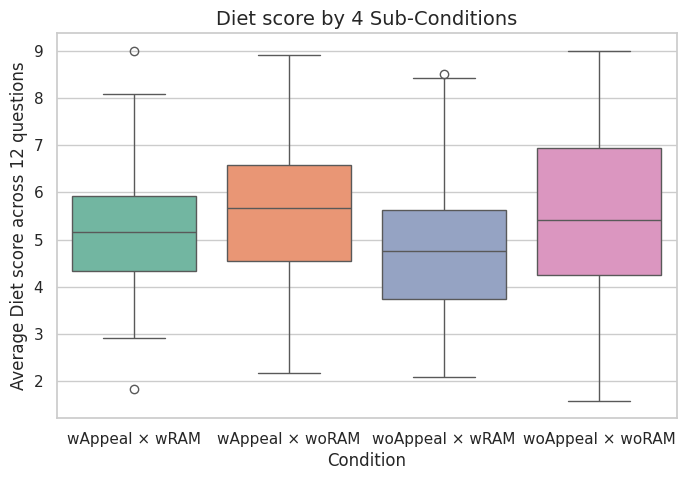

In [ ]:
label_map = {
    "wEO-wRAM":   "wAppeal × wRAM",
    "wEO-woRAM":  "wAppeal × woRAM",
    "woEO-wRAM":  "woAppeal × wRAM",
    "woEO-woRAM": "woAppeal × woRAM",
}

# Four groups Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df.assign(condition=df["condition"].map(label_map)),
            x='condition', y='diet_score',
            order=list(label_map.values()), palette="Set2")
plt.title('Diet score by 4 Sub-Conditions', fontsize=14)
plt.ylabel('Average Diet score across 12 questions')
plt.xlabel('Condition')
plt.show()

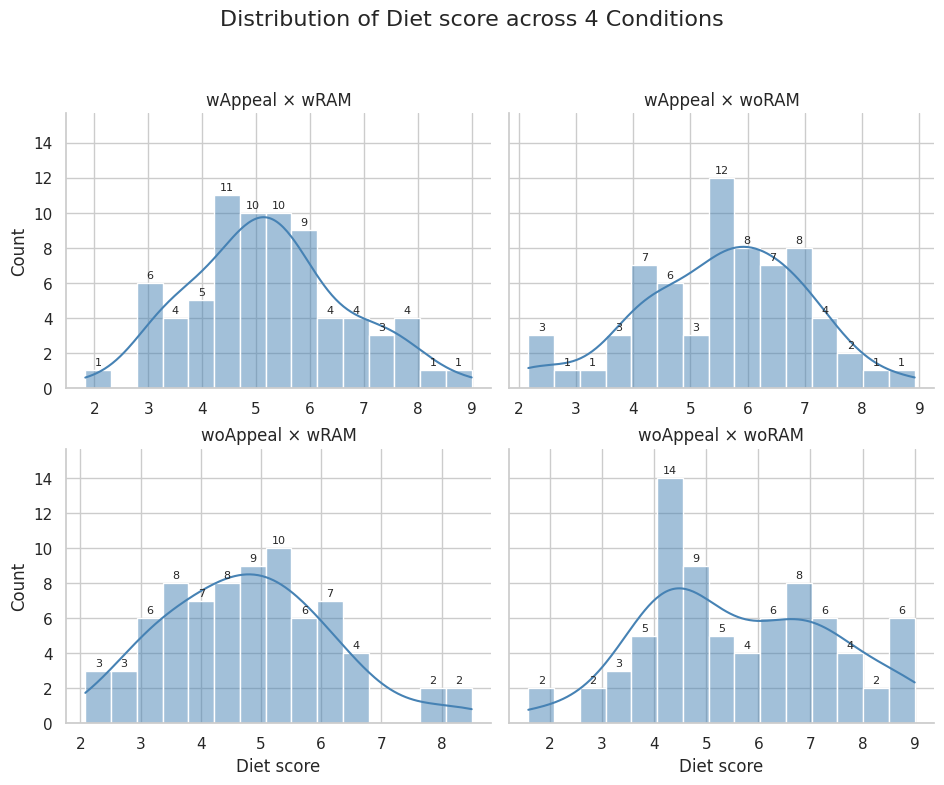

In [ ]:
label_map = {
    "wEO-wRAM":   "wAppeal × wRAM",
    "wEO-woRAM":  "wAppeal × woRAM",
    "woEO-wRAM":  "woAppeal × wRAM",
    "woEO-woRAM": "woAppeal × woRAM",
}

# Four Groups distribution (FacetGrid)
g = sns.FacetGrid(df.assign(condition=df["condition"].map(label_map)),
                  col="condition", col_order=list(label_map.values()),
                  col_wrap=2, height=4, aspect=1.2, sharex=False)
g.map_dataframe(sns.histplot, x="diet_score", kde=True, bins=15, color="steelblue")
g.set_axis_labels("Diet score", "Count")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Distribution of Diet score across 4 Conditions', fontsize=16)
for ax in g.axes.flat:
    for c in ax.containers:
        ax.bar_label(c, labels=[f"{int(v)}" if v > 0 else "" for v in c.datavalues],
                     fontsize=8, padding=2)
    ax.margins(y=0.12)
plt.show()

# **Hypothesis: Mouse Movement Speed**

H4. Participants who receive the hope appeal show fewer reversals than those who do not.

H5. Participants who use the RAM slider show fewer reversals than those who use the control slider.

H6. The greatest difference in mouse movement speed (pixels per minute) is observed between the Control group and the RAM + Hope Appeal group.

## Calculate Speed

In [ ]:
import os
import msgpack
import pandas as pd

folder_path = "./mouse_movement_data"
bin_files = sorted([f for f in os.listdir(folder_path) if f.endswith(".bin")])

target_questions = [f"q{i}-slider" for i in range(1, 13)]

results = []

for file_name in bin_files:

    file_path = os.path.join(folder_path, file_name)

    events = []

    # Read msgpack
    with open(file_path, "rb") as f:
        unpacker = msgpack.Unpacker(f, raw=False)

        for item in unpacker:
            if isinstance(item, list):
                events.extend(item)
            elif isinstance(item, dict):
                events.append(item)

    # store all drag speeds for each question
    question_speeds = {q: [] for q in target_questions}

    # currently active drags
    active_drags = {}

    def close_drag(element, drag, end_ts):
        """Record one drag segment. Shared by release and by end-of-stream flush."""
        duration_minutes = (end_ts - drag["start_ts"]) / 1000.0
        if duration_minutes > 0:
            speed = drag["distance"] / duration_minutes
            question_speeds[element].append(speed)

    for event in events:

        element = event.get("element")
        evt_type = event.get("type")
        ts = event.get("ts")
        value = event.get("value")
        phase = event.get("phase")

        # Only slider-change events carry `value`. Pointer events have `x` in
        # pixels, which is not comparable across viewport widths.
        if evt_type != "slider-change":
            continue

        if element not in target_questions:
            continue

        if value is None or ts is None:
            continue

        value = float(value)

        # ----------------------------
        # Drag starts
        # ----------------------------
        if phase == "press":
            if element in active_drags:
                prev = active_drags[element]
                if "end_ts" in prev:
                    close_drag(element, prev, prev["end_ts"])

            active_drags[element] = {
                "start_ts": ts,
                "last_value": value,
                "distance": 0.0,
            }

        # ----------------------------
        # Dragging / drag ends
        # ----------------------------
        elif phase in ("drag", "release"):

            if element in active_drags:

                drag = active_drags[element]

                drag["distance"] += abs(value - drag["last_value"])

                drag["last_value"] = value
                drag["end_ts"] = ts

                if phase == "release":
                    close_drag(element, drag, ts)
                    del active_drags[element]

    # -----------------------------------
    # Flush drags that never got a release event
    # release coverage: wRAM 87.6%, woRAM 69.0% -- skipping these would drop
    # ~18pp more drags from woRAM than wRAM, i.e. condition-dependent missingness
    # -----------------------------------
    for element, drag in list(active_drags.items()):
        if "end_ts" in drag:
            close_drag(element, drag, drag["end_ts"])
    active_drags.clear()

    # -----------------------------------
    # Average speed for each question
    # -----------------------------------
    subject_avg_speeds = []

    for q in target_questions:

        if len(question_speeds[q]) > 0:

            q_avg = sum(question_speeds[q]) / len(question_speeds[q])

            subject_avg_speeds.append(q_avg)

    # -----------------------------------
    # Subject DV
    # -----------------------------------
    if len(subject_avg_speeds) > 0:

        final_dv = sum(subject_avg_speeds) / len(subject_avg_speeds)

    else:

        final_dv = None

    results.append(
        {
            "subject_id": file_name.replace(".bin", ""),
            "avg_speed_units_per_sec": final_dv,
            "valid_q_count": len(subject_avg_speeds),
        }
    )

df_results = pd.DataFrame(results)

print(df_results.head(10))

df_results.to_csv("subject_speed_units_per_sec.csv", index=False)

print("\nSaved as subject_speed_units_per_sec.csv")

                                        subject_id  avg_speed_units_per_sec  \
0  002267ef-1893-4bb5-8b7b-cc0e6512c0d0_1783930782                 4.442981   
1  014d483f-deb7-463a-8600-c4e7e3f291b2_1784027952                 3.652728   
2  01dff38e-a919-483b-b6d7-cf30df8f6a2c_1783930816                 2.967417   
3  037b5b1a-6596-415d-9860-cfe1ce971b96_1783932088                 3.242320   
4  041f4926-3329-47ed-a32b-89075db59841_1784016685                 4.911787   
5  070dfe9d-695e-4966-aea5-c07c2b671b49_1783935395                 2.850130   
6  07d7b054-5f23-4184-ba7a-3cff3af1ec8d_1783930223                 3.008991   
7  0826e08e-f4c0-4b86-818d-8b11788e625b_1783933257                 2.627182   
8  08471ad8-cf33-4d58-a9cf-b1625e1d30e7_1783935959                      NaN   
9  091f35d9-e7fa-4ee2-8fb5-5a3ff9f788f5_1783939534                 7.233517   

   valid_q_count  
0             12  
1              9  
2             12  
3              7  
4              5  
5             12

## Merging 2 datasets

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scikit_posthocs as sp


df_speed = pd.read_csv('subject_speed_units_per_sec.csv')
df_cond = pd.read_csv('/content/drive/MyDrive/Leimen /Results - 2026 07 15/userid_condition.csv')

# left join to match subject speed dataset
df_speed['clean_id'] = df_speed['subject_id'].apply(lambda x: str(x).split('_')[0])
df = pd.merge(df_speed, df_cond, left_on='clean_id', right_on='respondent_id', how='left')

# drop average speed = 0
df = df.dropna(subset=['avg_speed_units_per_sec', 'condition'])

# Group HopeApeal and RAM
df['Factor_HopeAppeal'] = df['condition'].apply(lambda x: 'HopeAppeal' if str(x).startswith('wEO') else 'non-HopeAppeal')
df['Factor_RAM'] = df['condition'].apply(lambda x: 'RAM (wRAM)' if str(x).endswith('-wRAM') else 'non-RAM (woRAM)')


print(f"Sample size：{len(df)}")
print("\n")




Sample size：286




## Descriptive Statistics

In [ ]:
# general statistics
desc_stats = df.groupby('condition')['avg_speed_units_per_sec'].agg(N='count', Mean='mean', Median='median', Std='std').round(2)
print(desc_stats)
print("\n")

             N  Mean  Median   Std
condition                         
wEO-wRAM    73  4.37    4.34  1.76
wEO-woRAM   67  4.11    3.81  2.05
woEO-wRAM   73  4.08    3.73  1.63
woEO-woRAM  73  3.81    3.36  1.88




In [ ]:
print("-- Main Effect - Mann Whitney Test --")

# Test 1: HopeAppeal (wEO) vs non-HopeAppeal (woEO)
group_HopeAppeal = df[df['Factor_HopeAppeal'] == 'HopeAppeal']['avg_speed_units_per_sec']
group_nonHopeAppeal = df[df['Factor_HopeAppeal'] == 'non-HopeAppeal']['avg_speed_units_per_sec']
stat_ha, p_ha = stats.mannwhitneyu(group_HopeAppeal, group_nonHopeAppeal, alternative='two-sided')
print(f"▶ HopeAppeal vs non-HopeAppeal (wEO vs woEO):")
print(f"  median = {group_HopeAppeal.median():.3f} vs {group_nonHopeAppeal.median():.3f}")
print(f"  mean = {group_HopeAppeal.mean():.3f} vs {group_nonHopeAppeal.mean():.3f}")
print(f"  U-statistic = {stat_ha:.2f}, p-value = {p_ha:.4f}")

# Test 2: RAM vs non-RAM
group_RAM = df[df['Factor_RAM'] == 'RAM (wRAM)']['avg_speed_units_per_sec']
group_nonRAM = df[df['Factor_RAM'] == 'non-RAM (woRAM)']['avg_speed_units_per_sec']
stat_ram, p_ram = stats.mannwhitneyu(group_RAM, group_nonRAM, alternative='two-sided')
print(f"▶ RAM vs non-RAM:")
print(f"  median = {group_RAM.median():.3f} vs {group_nonRAM.median():.3f}")
print(f"  mean = {group_RAM.mean():.3f} vs {group_nonRAM.mean():.3f}")
print(f"  U-statistic = {stat_ram:.2f}, p-value = {p_ram:.4f}")
print("\n")

-- Main Effect - Mann Whitney Test --
▶ HopeAppeal vs non-HopeAppeal (wEO vs woEO):
  median = 4.064 vs 3.551
  mean = 4.243 vs 3.946
  U-statistic = 11612.00, p-value = 0.0466
▶ RAM vs non-RAM:
  median = 4.017 vs 3.597
  mean = 4.225 vs 3.952
  U-statistic = 11775.00, p-value = 0.0262




In [ ]:
print("-- H1: Hope Appeal effect, stratified by slider --")

for slider in ['RAM (wRAM)', 'non-RAM (woRAM)']:
    sub = df[df['Factor_RAM'] == slider]
    a = sub[sub['Factor_HopeAppeal'] == 'HopeAppeal']['avg_speed_units_per_sec']
    b = sub[sub['Factor_HopeAppeal'] == 'non-HopeAppeal']['avg_speed_units_per_sec']

    stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    r = 2 * stat / (len(a) * len(b)) - 1          # rank-biserial effect size

    print(f"\n▶ [{slider}] wEO vs woEO:")
    print(f"  n = {len(a)} vs {len(b)}")
    print(f"  median = {a.median():.3f} vs {b.median():.3f}")
    print(f"  U-statistic = {stat:.2f}, p-value = {p:.4f}, r = {r:+.3f}")

    # H1 predicts wEO < woEO; two-sided p carries no direction, so check medians
    hit = (p < .05) and (a.median() > b.median())
    warn = "  ⚠️ significant but direction is opposite" if (p < .05 and a.median() <= b.median()) else ""
    print(f"  -> {'✅ supports H1' if hit else '❌ not supported'}{warn}")

-- H1: Hope Appeal effect, stratified by slider --

▶ [RAM (wRAM)] wEO vs woEO:
  n = 73 vs 73
  median = 4.341 vs 3.728
  U-statistic = 3125.00, p-value = 0.0718, r = +0.173
  -> ❌ not supported

▶ [non-RAM (woRAM)] wEO vs woEO:
  n = 67 vs 73
  median = 3.809 vs 3.365
  U-statistic = 2673.00, p-value = 0.3437, r = +0.093
  -> ❌ not supported


In [ ]:
# 4. Four Groups：Kruskal-Wallis & Dunn's Posthoc

print("-- Four Groups：Kruskal-Wallis & Dunn's Posthoc --")
conds = df['condition'].unique()
kw_data = [df[df['condition'] == c]['avg_speed_units_per_sec'] for c in conds]

stat_kw, p_kw = stats.kruskal(*kw_data)
print(f"Kruskal-Wallis H-statistic = {stat_kw:.2f}, p-value = {p_kw:.4f}")

dunn_matrix = sp.posthoc_dunn(df, val_col='avg_speed_units_per_sec', group_col='condition', p_adjust='holm')
print("\n▶ Dunn's post-hoc (p-value matrix, Holm correction):")
print(dunn_matrix.round(4))
print("\n")

-- Four Groups：Kruskal-Wallis & Dunn's Posthoc --
Kruskal-Wallis H-statistic = 8.90, p-value = 0.0306

▶ Dunn's post-hoc (p-value matrix, Holm correction):
            wEO-wRAM  wEO-woRAM  woEO-wRAM  woEO-woRAM
wEO-wRAM      1.0000     0.3376     0.3679      0.0191
wEO-woRAM     0.3376     1.0000     0.8575      0.6189
woEO-wRAM     0.3679     0.8575     1.0000      0.6189
woEO-woRAM    0.0191     0.6189     0.6189      1.0000




In [ ]:
from itertools import combinations
from scipy import stats

VAL = 'avg_speed_units_per_sec'

label_map = {
    "wEO-wRAM":   "wAppeal × wRAM",
    "wEO-woRAM":  "wAppeal × woRAM",
    "woEO-wRAM":  "woAppeal × wRAM",
    "woEO-woRAM": "woAppeal × woRAM",
}
order = list(label_map.keys())

print("\n-- Pairwise Mann-Whitney U --")
mw_matrix = sp.posthoc_mannwhitney(df, val_col=VAL, group_col='condition', p_adjust='holm')
mw_matrix = mw_matrix.loc[order, order]
print("\n▶ Pairwise Mann-Whitney U (p-value matrix, Holm correction):")
print(mw_matrix.rename(index=label_map, columns=label_map).round(4))

med = df.groupby('condition')[VAL].median()

print("\n▶ Pairwise differences (median diff / rank-biserial r):")
rows = []
for a, b in combinations(order, 2):
    xa = df.loc[df['condition'] == a, VAL]
    xb = df.loc[df['condition'] == b, VAL]
    u, _ = stats.mannwhitneyu(xa, xb, alternative='two-sided')
    r_rb = 2 * u / (len(xa) * len(xb)) - 1        # −1 ~ +1, 正值代表 a > b
    rows.append({
        "comparison":  f"{label_map[a]} − {label_map[b]}",
        "median_diff": med[a] - med[b],
        "U":           u,
        "r_rb":        r_rb,
        "p_holm":      mw_matrix.loc[a, b],
    })

mw_table = pd.DataFrame(rows)
mw_table["sig"] = np.where(mw_table["p_holm"] < .05, "*", "")
print(mw_table.round(4).to_string(index=False))


-- Pairwise Mann-Whitney U --

▶ Pairwise Mann-Whitney U (p-value matrix, Holm correction):
                  wAppeal × wRAM  wAppeal × woRAM  woAppeal × wRAM  \
wAppeal × wRAM            1.0000           0.3590           0.3590   
wAppeal × woRAM           0.3590           1.0000           0.8446   
woAppeal × wRAM           0.3590           0.8446           1.0000   
woAppeal × woRAM          0.0197           0.6874           0.5196   

                  woAppeal × woRAM  
wAppeal × wRAM              0.0197  
wAppeal × woRAM             0.6874  
woAppeal × wRAM             0.5196  
woAppeal × woRAM            1.0000  

▶ Pairwise differences (median diff / rank-biserial r):
                        comparison  median_diff      U    r_rb  p_holm sig
  wAppeal × wRAM − wAppeal × woRAM       0.5325 2853.0  0.1666  0.3590    
  wAppeal × wRAM − woAppeal × wRAM       0.6138 3125.0  0.1728  0.3590    
 wAppeal × wRAM − woAppeal × woRAM       0.9768 3416.0  0.2820  0.0197   *
 wAppeal × woR

## Plots

/tmp/ipykernel_881/265258385.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Factor_HopeAppeal', y='avg_speed_units_per_sec', palette=["#72B6A1", "#E9967A"])


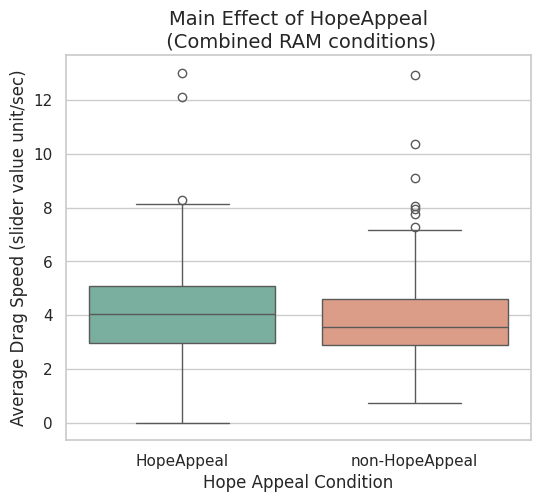

In [ ]:
sns.set_theme(style="whitegrid")

# HopeAppeal Main effect Boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='Factor_HopeAppeal', y='avg_speed_units_per_sec', palette=["#72B6A1", "#E9967A"])
plt.title('Main Effect of HopeAppeal\n (Combined RAM conditions)', fontsize=14)
plt.ylabel('Average Drag Speed (slider value unit/sec)')
plt.xlabel('Hope Appeal Condition')
plt.show()

print("\n")


/tmp/ipykernel_881/1369846547.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Factor_RAM', y='avg_speed_units_per_sec', palette=["#72B6A1", "#E9967A"])


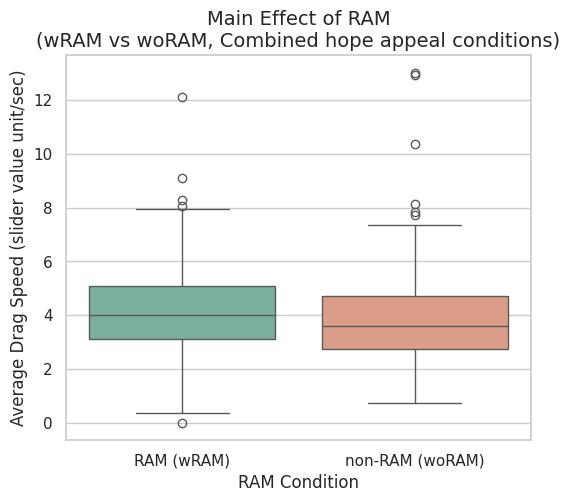

In [ ]:
sns.set_theme(style="whitegrid")

# RAM Main effect Boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='Factor_RAM', y='avg_speed_units_per_sec', palette=["#72B6A1", "#E9967A"])
plt.title('Main Effect of RAM\n(wRAM vs woRAM, Combined hope appeal conditions)', fontsize=14)
plt.ylabel('Average Drag Speed (slider value unit/sec)')
plt.xlabel('RAM Condition')
plt.show()

print("\n")

/tmp/ipykernel_881/1452963801.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df.assign(condition=df["condition"].map(label_map)),


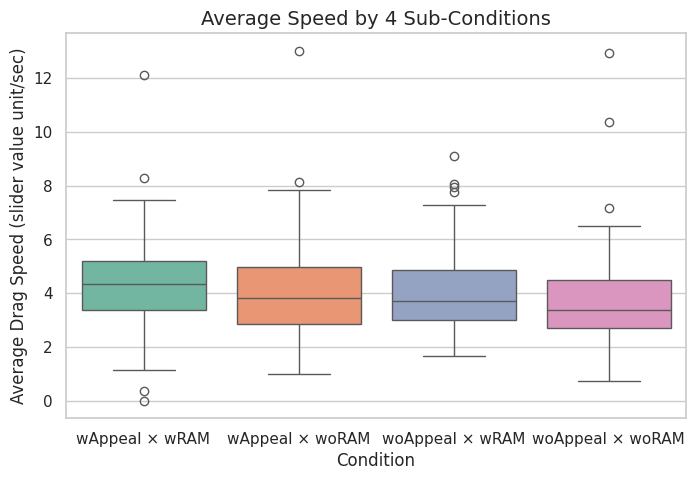

In [ ]:
label_map = {
    "wEO-wRAM":   "wAppeal × wRAM",
    "wEO-woRAM":  "wAppeal × woRAM",
    "woEO-wRAM":  "woAppeal × wRAM",
    "woEO-woRAM": "woAppeal × woRAM",
}

# Four groups Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df.assign(condition=df["condition"].map(label_map)),
            x='condition', y='avg_speed_units_per_sec',
            order=list(label_map.values()), palette="Set2")
plt.title('Average Speed by 4 Sub-Conditions', fontsize=14)
plt.ylabel('Average Drag Speed (slider value unit/sec)')
plt.xlabel('Condition')
plt.show()

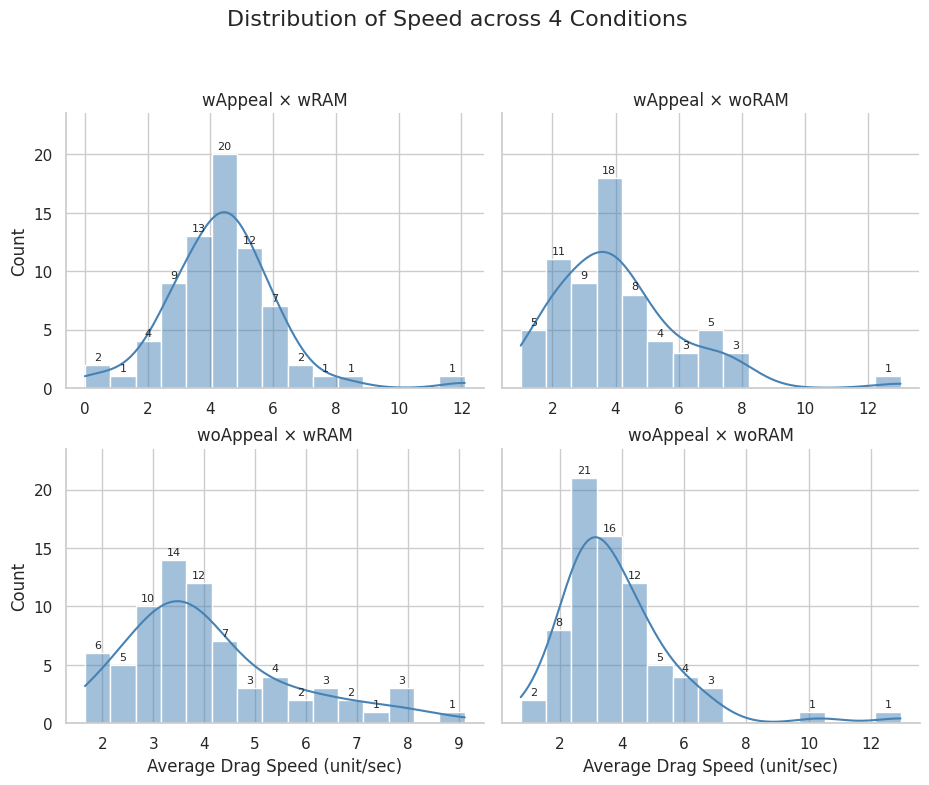

In [ ]:
label_map = {
    "wEO-wRAM":   "wAppeal × wRAM",
    "wEO-woRAM":  "wAppeal × woRAM",
    "woEO-wRAM":  "woAppeal × wRAM",
    "woEO-woRAM": "woAppeal × woRAM",
}

# Four Groups distribution (FacetGrid)
g = sns.FacetGrid(df.assign(condition=df["condition"].map(label_map)),
                  col="condition", col_order=list(label_map.values()),
                  col_wrap=2, height=4, aspect=1.2, sharex=False)
g.map_dataframe(sns.histplot, x="avg_speed_units_per_sec", kde=True, bins=15, color="steelblue")
g.set_axis_labels("Average Drag Speed (unit/sec)", "Count")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Distribution of Speed across 4 Conditions', fontsize=16)
for ax in g.axes.flat:
    for c in ax.containers:
        ax.bar_label(c, labels=[f"{int(v)}" if v > 0 else "" for v in c.datavalues],
                     fontsize=8, padding=2)
    ax.margins(y=0.12)
plt.show()